In [444]:
# Jupyter notebooks have problems with imports from parent folder, so let's change the path
from jupyter_utils import change_path_to_parent
change_path_to_parent()

import matplotlib
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2
from optmethods.first_order import AdgdAccel
from optmethods.datasets import get_dataset


from optmethods.loss import LogisticRegression, LogSumExp
from optmethods.second_order import Newton
from optmethods.second_order import CaCuAdGD
from optmethods.second_order import Cubic, AccCubic, SuperCubic
from optmethods.second_order import CaCuN, AccCaCuN
from optmethods.second_order import Arc, Cubic, Newton, RegNewton
from optmethods.second_order import CaCuGN, AdaN, AdaNWU, CaCuAdaN, CaCuAdaNP#, CaCuAdaNFOO, CaCuAdaNP
from optmethods.quasi_newton import Bfgs, Dfp, Lbfgs, Sr1, Shorr
from optmethods.first_order import Adgd, AdgdAccel, Gd, Nesterov, Ogm, Polyak, RestNest, NestLine
from optmethods.utils import get_trace, relative_round

sns.set(style="whitegrid", context="talk", palette=sns.color_palette("bright"), color_codes=False)
matplotlib.rc('font', family='sans-serif') 
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['figure.figsize'] = (9, 6)

markers = ['s', 'o', '^', '*', 'v', 'X', '+', 'P', '.', 6, 7]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [538]:
dataset = 'covtype'
A, b = get_dataset(dataset)

b = np.asarray(b).ravel()
u = np.unique(b)
if u.size == 2 and set(u) <= {0,1}:
    b = b.astype(np.float64)
else:
 b = (b == 1).astype(np.float64)

n, dim = A.shape
A = A.astype(np.float64, copy=False)
A /= A.max()

l2 = 0.0
loss = LogisticRegression(A, b, l1=0, l2=l2)

x0 = np.zeros(dim)
# loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
loss.f_opt = 0.4657138629352897

Running optimizer: AdaN
CPU times: user 4min 30s, sys: 570 ms, total: 4min 30s
Wall time: 6.03 s
Running optimizer: AdaN+
CPU times: user 4min 5s, sys: 631 ms, total: 4min 6s
Wall time: 4.91 s
Running optimizer: CaCuAdaN
CPU times: user 4min 41s, sys: 547 ms, total: 4min 42s
Wall time: 6.51 s
Running optimizer: CaCuAdaN+
CPU times: user 5min 57s, sys: 572 ms, total: 5min 58s
Wall time: 6.21 s


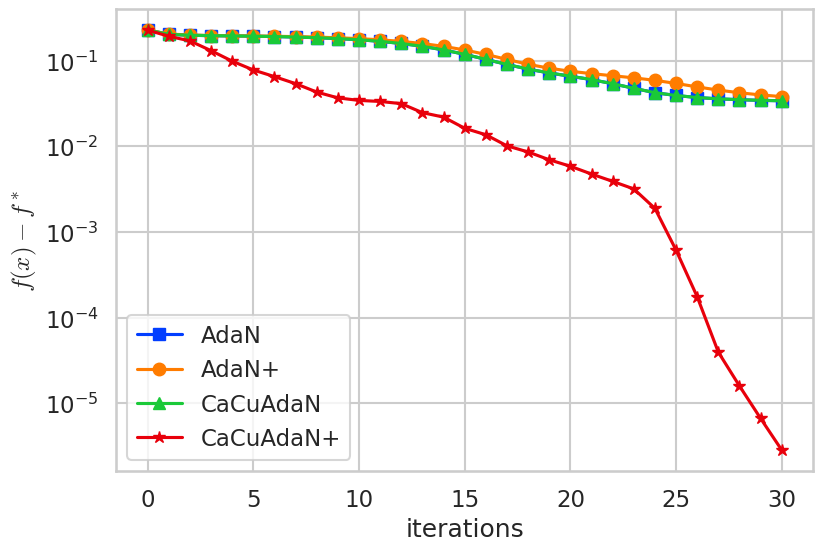

In [ ]:
adan = RegNewton(loss=loss, adaptive=True, use_line_search=True, label='AdaN')
adanp = RegNewton(loss=loss, adaptive=True, use_line_search=False, label='AdaN+')
cacuadan = CaCuAdaN(loss=loss, label='CaCuAdaN')
cacuadanp =  CaCuAdaNP(loss=loss, label='CaCuAdaN+')

optimizers = [adan, adanp, cacuadan, cacuadanp]

it_max = 30
time=False
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, it_max=it_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadan_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

In [540]:
adan = RegNewton(loss=loss, adaptive=True, use_line_search=True, label='AdaN')
adanp = RegNewton(loss=loss, adaptive=True, use_line_search=False, label='AdaN+')
cacuadan = CaCuAdaN(loss=loss, label='CaCuAdaN')

Running optimizer: AdaN
CPU times: user 7min 26s, sys: 1.02 s, total: 7min 27s
Wall time: 10.1 s
Running optimizer: AdaN+
CPU times: user 8min 21s, sys: 1.38 s, total: 8min 22s
Wall time: 10.1 s
Running optimizer: CaCuAdaN
CPU times: user 7min 16s, sys: 915 ms, total: 7min 17s
Wall time: 10.1 s
Running optimizer: CaCuAdaN+
CPU times: user 9min 36s, sys: 1.07 s, total: 9min 37s
Wall time: 10.1 s


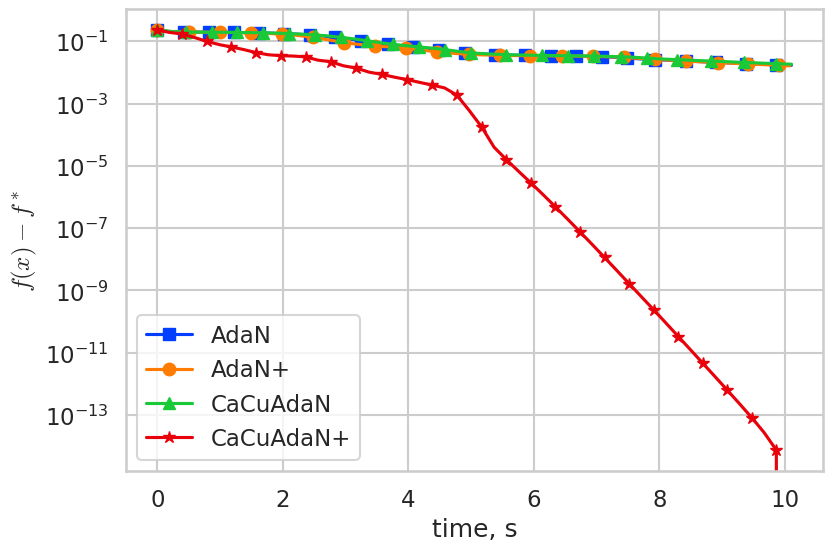

In [ ]:
cacuadanp =  CaCuAdaNP(loss=loss, label='CaCuAdaN+')

optimizers = [adan, adanp, cacuadan, cacuadanp]

time=True
t_max = 10
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, t_max=t_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker, time=time, use_ls_its=False)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadan_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

In [536]:
dataset = 'w8a'
A, b = get_dataset(dataset)

n, dim = A.shape
# A = A.astype(np.float64, copy=False)

l2 = 0.0
loss = LogisticRegression(A, b, l1=0, l2=l2)

x0 = np.zeros(dim)
# loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
fopt=np.float64(0.1108110124131768)

The passed labels have values in the set {-1, 1}. Changing them to {0, 1}


Running optimizer: AdaN
CPU times: user 3.81 s, sys: 1.75 s, total: 5.56 s
Wall time: 5.56 s
Running optimizer: AdaN+
CPU times: user 3.69 s, sys: 1.71 s, total: 5.4 s
Wall time: 5.4 s
Running optimizer: CaCuAdaN
self.it=0
self.it=1
self.it=2
self.it=3
self.it=4
self.it=5
self.it=6
self.it=7
self.it=8
self.it=9
self.it=10
self.it=11
CPU times: user 3.04 s, sys: 1.32 s, total: 4.36 s
Wall time: 4.36 s
Running optimizer: CaCuAdaN+


LinAlgError: Singular matrix

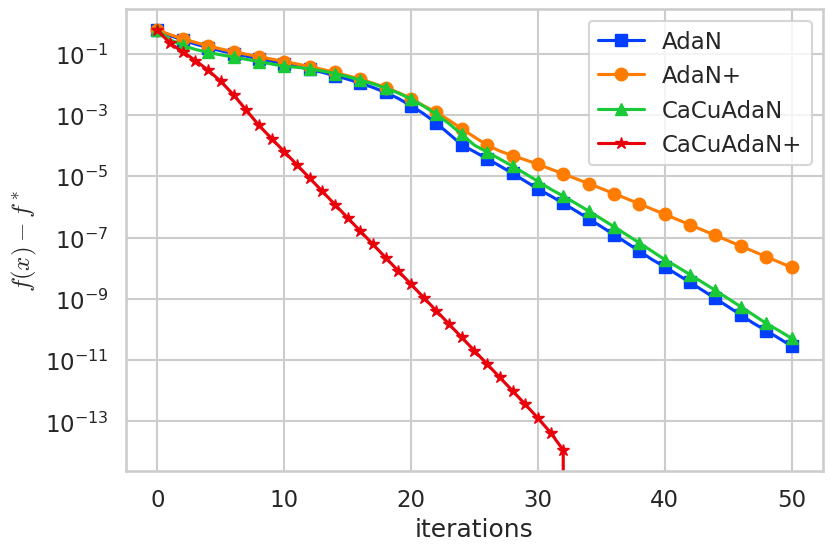

In [ ]:
adan = RegNewton(loss=loss, adaptive=True, use_line_search=True, label='AdaN')
adanp = RegNewton(loss=loss, adaptive=True, use_line_search=False, label='AdaN+')
cacuadan = CaCuAdaN(loss=loss, label='CaCuAdaN')
cacuadanp =  CaCuAdaNP(loss=loss, label='CaCuAdaN+')

optimizers = [adan, adanp, cacuadan, cacuadanp]


time=False
it_max = 50
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, it_max=it_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadan_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

Running optimizer: AdaN
CPU times: user 3.37 s, sys: 1.66 s, total: 5.03 s
Wall time: 5.03 s
Running optimizer: AdaN+
CPU times: user 3.2 s, sys: 1.88 s, total: 5.08 s
Wall time: 5.08 s
Running optimizer: CaCuAdaN
self.it=0
self.it=1
self.it=2
self.it=3
self.it=4
self.it=5
self.it=6
self.it=7
self.it=8
self.it=9
self.it=10
self.it=11
CPU times: user 3.29 s, sys: 1.75 s, total: 5.04 s
Wall time: 5.04 s
Running optimizer: CaCuAdaN+


LinAlgError: Singular matrix

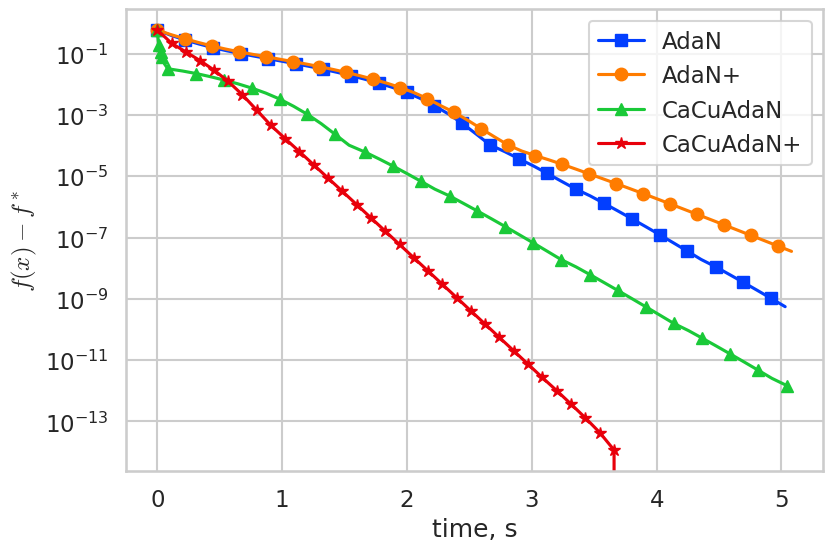

In [ ]:
adan = RegNewton(loss=loss, adaptive=True, use_line_search=True, label='AdaN')
adanp = RegNewton(loss=loss, adaptive=True, use_line_search=False, label='AdaN+')
cacuadan = CaCuAdaN(loss=loss, label='CaCuAdaN')
cacuadanp =  CaCuAdaNP(loss=loss, label='CaCuAdaN+')

optimizers = [adan, adanp, cacuadan, cacuadanp]


time=True
t_max = 5
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, t_max=t_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker, time=time)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadan_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

In [ ]:
dataset = 'mushrooms'
A, b = get_dataset(dataset)

n, dim = A.shape
A = A.astype(np.float64, copy=False)

l2 = 0.0
loss = LogisticRegression(A, b, l1=0, l2=l2)
x0 = np.zeros(dim)
loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
# fopt=np.float64(0.1108110124131768)

The passed labels have values in the set {1, 2}. Changing them to {0, 1}
fopt=np.float64(2.772122812435447e-18)


Running optimizer: AdaN
CPU times: user 211 ms, sys: 2 μs, total: 211 ms
Wall time: 210 ms
Running optimizer: AdaN+
CPU times: user 210 ms, sys: 0 ns, total: 210 ms
Wall time: 210 ms
Running optimizer: CaCuAdaN
CPU times: user 217 ms, sys: 0 ns, total: 217 ms
Wall time: 216 ms
Running optimizer: CaCuAdaN+
CPU times: user 254 ms, sys: 8 μs, total: 254 ms
Wall time: 254 ms


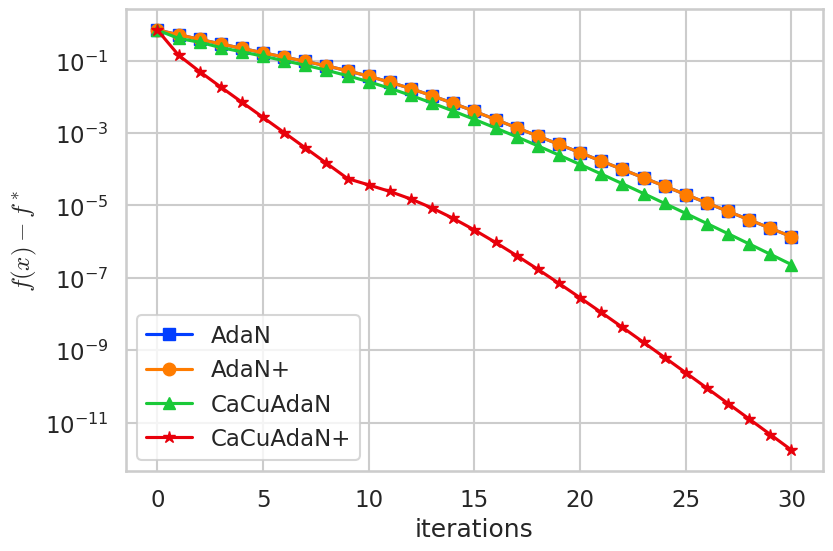

In [584]:
adan = RegNewton(loss=loss, adaptive=True, use_line_search=False, label='AdaN')
adanp = RegNewton(loss=loss, adaptive=True, use_line_search=False, label='AdaN+')
cacuadan = CaCuAdaN(loss=loss, label='CaCuAdaN')
cacuadanp =  CaCuAdaNP(loss=loss, label='CaCuAdaN+')

optimizers = [adan, adanp, cacuadan, cacuadanp]

time=False
it_max = 30
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, it_max=it_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadan_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

Running optimizer: AdaN
CPU times: user 507 ms, sys: 16 μs, total: 507 ms
Wall time: 506 ms
Running optimizer: AdaN+
CPU times: user 504 ms, sys: 0 ns, total: 504 ms
Wall time: 504 ms
Running optimizer: CaCuAdaN
CPU times: user 565 ms, sys: 2 μs, total: 565 ms
Wall time: 565 ms
Running optimizer: CaCuAdaN+
CPU times: user 500 ms, sys: 0 ns, total: 500 ms
Wall time: 500 ms


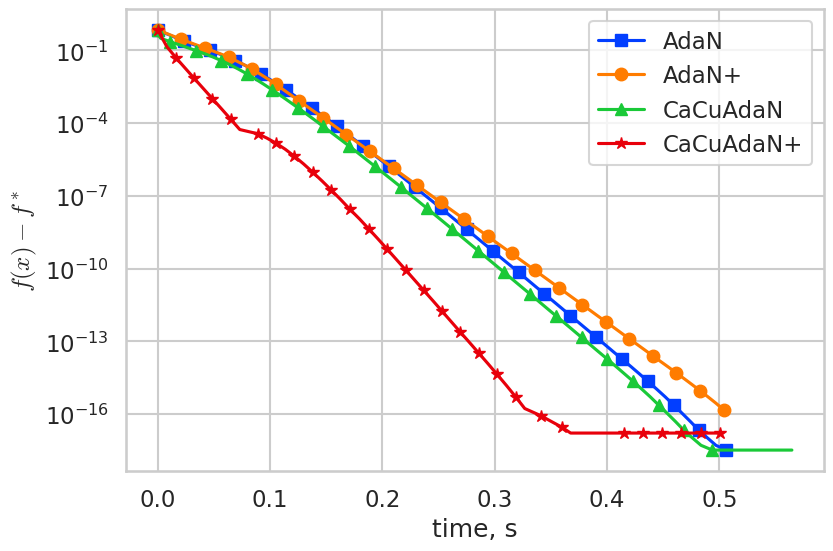

In [585]:
adan = RegNewton(loss=loss, adaptive=True, use_line_search=True, label='AdaN')
adanp = RegNewton(loss=loss, adaptive=True, use_line_search=False, label='AdaN+')
cacuadan = CaCuAdaN(loss=loss, label='CaCuAdaN')
cacuadanp =  CaCuAdaNP(loss=loss, label='CaCuAdaN+')

optimizers = [adan, adanp, cacuadan, cacuadanp]

time=True
t_max = 0.5
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, t_max=t_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker, time=time)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadan_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

## LogSumExp

In [570]:
n, dim = 2000, 1400
n, dim = 500, 200
least_squares_term = False
max_smoothing = 0.05
l2 = 0.0
loss = LogSumExp(n=n, dim=dim, least_squares_term=least_squares_term, l2=l2, max_smoothing=max_smoothing)
# x0 = rng.normal(scale=0.5, size=dim)
x0 = np.ones(dim)
loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)

fopt=np.float64(4.135211534756795)


Running optimizer: AdaN


/home/nazarii.tupitsa/opt_methods/optmethods/line_search/reg_newton_ls.py:55: RuntimeWarning: overflow encountered in scalar divide
  self.H /= self.backtracking
/home/nazarii.tupitsa/opt_methods/optmethods/line_search/reg_newton_ls.py:57: RuntimeWarning: invalid value encountered in multiply
  x_new = x - np.linalg.solve(hess + identity_coef*np.eye(self.loss.dim), grad)


CPU times: user 1min 20s, sys: 0 ns, total: 1min 20s
Wall time: 2.51 s
Running optimizer: AdaN+
CPU times: user 40.6 s, sys: 0 ns, total: 40.6 s
Wall time: 1.28 s
Running optimizer: CaCuAdaN


/home/nazarii.tupitsa/opt_methods/optmethods/second_order/CaCuAdaN.py:74: RuntimeWarning: overflow encountered in scalar divide
  self.H /= self.backtracking
/home/nazarii.tupitsa/opt_methods/optmethods/second_order/CaCuAdaN.py:76: RuntimeWarning: invalid value encountered in multiply
  x_new = x - np.linalg.solve(hess + identity_coef*np.eye(self.loss.dim), grad)


CPU times: user 1min 18s, sys: 0 ns, total: 1min 18s
Wall time: 2.45 s
Running optimizer: CaCuAdaN+
CPU times: user 58.9 s, sys: 0 ns, total: 58.9 s
Wall time: 1.84 s


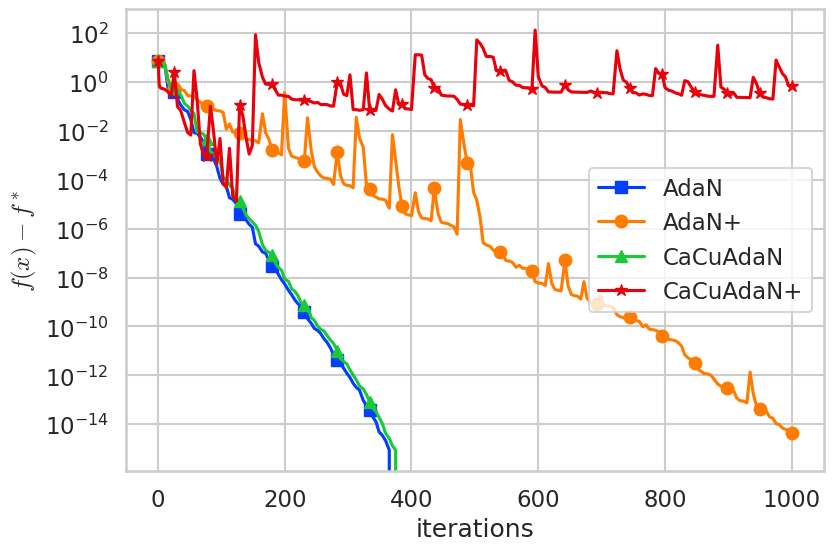

In [574]:
adan = RegNewton(loss=loss, adaptive=True, use_line_search=True, label='AdaN')
adanp = RegNewton(loss=loss, adaptive=True, use_line_search=False, label='AdaN+')
cacuadan = CaCuAdaN(loss=loss, label='CaCuAdaN')
cacuadanp =  CaCuAdaNP(loss=loss, label='CaCuAdaN+')

optimizers = [adan, adanp, cacuadan, cacuadanp]

time=False
it_max = 1000
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, it_max=it_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker)
plt.yscale('log')
plt.legend()
plt.savefig(f'logsumexp_{n,dim,max_smoothing}_cacuadan_{"t" if time == True else "i"}.pdf', bbox_inches='tight')

Running optimizer: AdaN


/home/nazarii.tupitsa/opt_methods/optmethods/line_search/reg_newton_ls.py:55: RuntimeWarning: overflow encountered in scalar divide
  self.H /= self.backtracking
/home/nazarii.tupitsa/opt_methods/optmethods/line_search/reg_newton_ls.py:57: RuntimeWarning: invalid value encountered in multiply
  x_new = x - np.linalg.solve(hess + identity_coef*np.eye(self.loss.dim), grad)


CPU times: user 1min 3s, sys: 0 ns, total: 1min 3s
Wall time: 2 s
Running optimizer: AdaN+
CPU times: user 1min 3s, sys: 0 ns, total: 1min 3s
Wall time: 2 s
Running optimizer: CaCuAdaN


/home/nazarii.tupitsa/opt_methods/optmethods/second_order/CaCuAdaN.py:74: RuntimeWarning: overflow encountered in scalar divide
  self.H /= self.backtracking
/home/nazarii.tupitsa/opt_methods/optmethods/second_order/CaCuAdaN.py:76: RuntimeWarning: invalid value encountered in multiply
  x_new = x - np.linalg.solve(hess + identity_coef*np.eye(self.loss.dim), grad)


CPU times: user 1min 4s, sys: 0 ns, total: 1min 4s
Wall time: 2 s
Running optimizer: CaCuAdaN+
CPU times: user 1min 4s, sys: 0 ns, total: 1min 4s
Wall time: 2 s


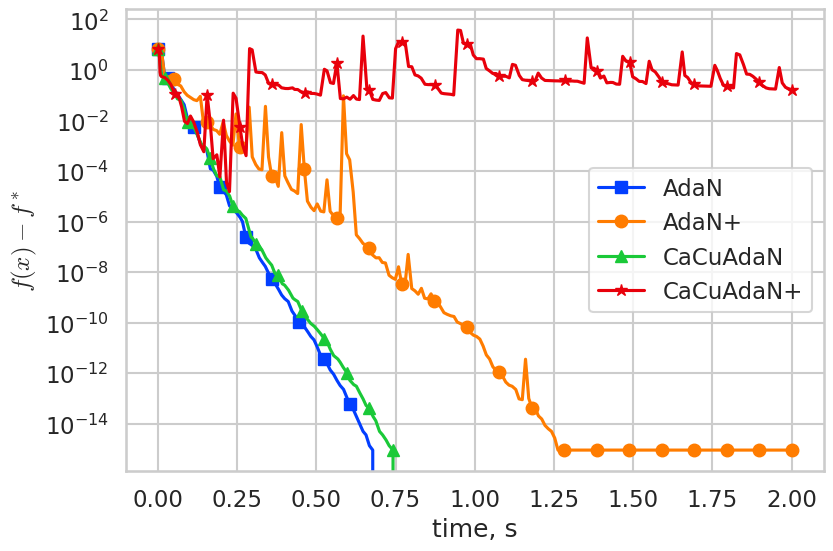

In [ ]:
adan = RegNewton(loss=loss, adaptive=True, use_line_search=True, label='AdaN')
adanp = RegNewton(loss=loss, adaptive=True, use_line_search=False, label='AdaN+')
cacuadan = CaCuAdaN(loss=loss, label='CaCuAdaN')
cacuadanp =  CaCuAdaNP(loss=loss, label='CaCuAdaN+')

optimizers = [adan, adanp, cacuadan, cacuadanp]

time=True
t_max = 2
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, t_max=t_max)
    opt.compute_loss_of_iterates()

for opt, marker in zip(optimizers, markers):
    opt.trace.plot_losses(marker=marker, time=time)
plt.yscale('log')
plt.legend()
plt.savefig(f'logsumexp_{n,dim,max_smoothing}_cacuadan_{"t" if time == True else "i"}.pdf', bbox_inches='tight')